## Ансамбли и полносвязные нейронные сети
В этом ноутбуке вам нужно обучить модели на датасете классификации из предыдущего ноутбука и сравнить результаты. Вам будет предоставлен baseline, на основе которого вы будете доделывать предсказывающие модели. Оценка лабы будет зависеть от ROC-AUC на тестовых данных по следующим критериям:
\n
AUC - на тестовых данных
- $AUC \leq 0.76$ - 0 баллов
- $0.76 < AUC \leq 0.77$ - 2 балла
- $0.77 < AUC \leq 0.78$ - 4 балла
- $0.78 < AUC \leq 0.79$ - 6 баллов
- $0.79 < AUC \leq 0.80$ - 8 баллов
- $AUC > 0.80$ - 10 баллов


In [8]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

from sklearn.metrics import roc_auc_score, precision_score, recall_score, roc_curve, accuracy_score

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [10]:
# 1. Загрузка данных
data = pd.read_csv('german.csv', sep=';')
print("Shape данных:", data.shape)
print("\nПервые 5 строк:")
print(data.head())
print("\nИнформация о данных:")
print(data.info())

Shape данных: (1000, 21)

Первые 5 строк:
   Creditability  Account_Balance  Duration_of_Credit_monthly  \
0              1                1                          18   
1              1                1                           9   
2              1                2                          12   
3              1                1                          12   
4              1                1                          12   

   Payment_Status_of_Previous_Credit  Purpose  Credit_Amount  \
0                                  4        2           1049   
1                                  4        0           2799   
2                                  2        9            841   
3                                  4        0           2122   
4                                  4        0           2171   

   Value_Savings_Stocks  Length_of_current_employment  Instalment_per_cent  \
0                     1                             2                    4   
1                     1   

In [11]:
# 2. Предобработка данных
# Разделение на признаки и целевую переменную
X = data.iloc[:, 1:].to_numpy()
y = data.iloc[:, 0].to_numpy()

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Масштабирование признаков (важно для MLP и SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Размер обучающей выборки: {X_train.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")
print(f"Количество признаков: {X_train.shape[1]}")

Размер обучающей выборки: 800
Размер тестовой выборки: 200
Количество признаков: 20


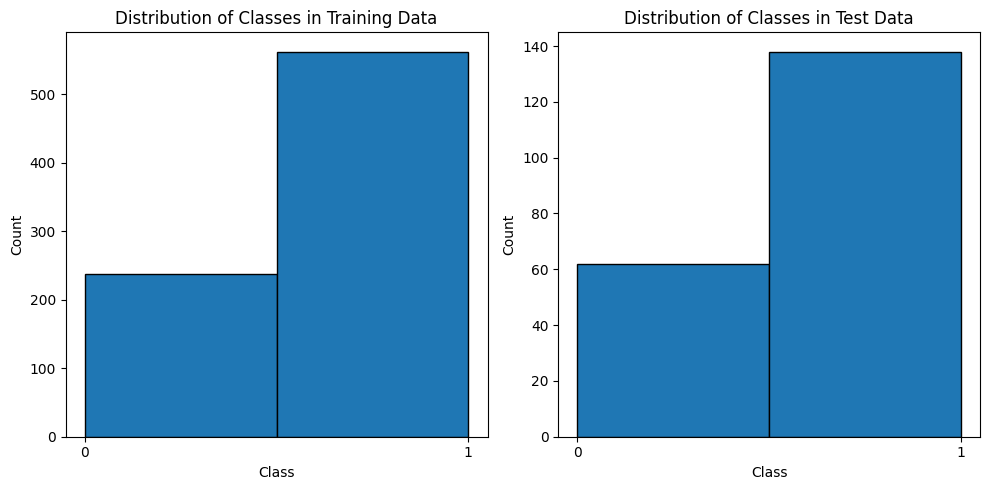

Баланс классов в training: 0.70
Баланс классов в test: 0.69


In [12]:
# Распределение классов
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(y_train, bins=2, edgecolor='k')
plt.xticks([0, 1])
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Distribution of Classes in Training Data')

plt.subplot(1, 2, 2)
plt.hist(y_test, bins=2, edgecolor='k')
plt.xticks([0, 1])
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Distribution of Classes in Test Data')

plt.tight_layout()
plt.show()
print(f"Баланс классов в training: {np.mean(y_train):.2f}")
print(f"Баланс классов в test: {np.mean(y_test):.2f}")

## 3. Обучение базовых моделей (Baseline)

In [13]:
# Обучение Random Forest (baseline)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Прогноз на тестовых данных
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

# Расчет метрик для Random Forest
rf_roc_auc = roc_auc_score(y_test, rf_proba)
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)

print("Random Forest метрики (baseline):")
print(f"ROC AUC: {rf_roc_auc:.4f}")
print(f"Accuracy: {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall: {rf_recall:.4f}")

Random Forest метрики (baseline):
ROC AUC: 0.7633
Accuracy: 0.7600
Precision: 0.7848
Recall: 0.8986


In [14]:
# Обучение Gradient Boosting (baseline)
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

# Прогноз на тестовых данных
gb_pred = gb_model.predict(X_test)
gb_proba = gb_model.predict_proba(X_test)[:, 1]

# Расчет метрик для Gradient Boosting
gb_roc_auc = roc_auc_score(y_test, gb_proba)
gb_accuracy = accuracy_score(y_test, gb_pred)
gb_precision = precision_score(y_test, gb_pred)
gb_recall = recall_score(y_test, gb_pred)

print("Gradient Boosting метрики (baseline):")
print(f"ROC AUC: {gb_roc_auc:.4f}")
print(f"Accuracy: {gb_accuracy:.4f}")
print(f"Precision: {gb_precision:.4f}")
print(f"Recall: {gb_recall:.4f}")

Gradient Boosting метрики (baseline):
ROC AUC: 0.7500
Accuracy: 0.7350
Precision: 0.7891
Recall: 0.8406


In [15]:
# Обучение MLP (Multi-Layer Perceptron) нейронной сети (baseline)
mlp_model = MLPClassifier(hidden_layer_sizes=(30,), max_iter=500, random_state=42)
mlp_model.fit(X_train_scaled, y_train)

# Прогноз на тестовых данных
mlp_pred = mlp_model.predict(X_test_scaled)
mlp_proba = mlp_model.predict_proba(X_test_scaled)[:, 1]

# Расчет метрик для MLP нейронной сети
mlp_roc_auc = roc_auc_score(y_test, mlp_proba)
mlp_accuracy = accuracy_score(y_test, mlp_pred)
mlp_precision = precision_score(y_test, mlp_pred)
mlp_recall = recall_score(y_test, mlp_pred)

print("MLP (Neural Network) метрики (baseline):")
print(f"ROC AUC: {mlp_roc_auc:.4f}")
print(f"Accuracy: {mlp_accuracy:.4f}")
print(f"Precision: {mlp_precision:.4f}")
print(f"Recall: {mlp_recall:.4f}")

MLP (Neural Network) метрики (baseline):
ROC AUC: 0.7799
Accuracy: 0.7550
Precision: 0.8201
Recall: 0.8261


## 4. Эксперименты с оптимизацией гиперпараметров

### 4.1 Оптимизация Gradient Boosting 
GB : был 0.7298 стал 0.7654
CV ROC AUC = 0.8025

In [28]:
# Оптимизация гиперпараметров Gradient Boosting с помощью GridSearchCV
print("Оптимизация Gradient Boosting...")

# Используем подвыборку для быстрого поиска
gb_param_grid = {
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.01, 0.3, 0.05],
    'max_depth': [3, 4, 5],
    'min_samples_split': [5, 10, 15],
    'subsample': [0.6, 0.7, 0.8]
}

gb_base = GradientBoostingClassifier(random_state=42)

# Grid search с 3-fold cross-validation
gb_grid = GridSearchCV(gb_base, gb_param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=0)
gb_grid.fit(X_train, y_train)

print(f"Лучшие параметры: {gb_grid.best_params_}")
print(f"Лучший CV ROC AUC: {gb_grid.best_score_:.4f}")

# Оценка на тестовой выборке
gb_opt_model = gb_grid.best_estimator_
gb_opt_pred = gb_opt_model.predict(X_test)
gb_opt_proba = gb_opt_model.predict_proba(X_test)[:, 1]
gb_opt_roc_auc = roc_auc_score(y_test, gb_opt_proba)

print(f"Тестовый ROC AUC (оптимизированный GB): {gb_opt_roc_auc:.4f}")

Оптимизация Gradient Boosting...
Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 4, 'min_samples_split': 10, 'n_estimators': 150, 'subsample': 0.7}
Лучший CV ROC AUC: 0.8025
Тестовый ROC AUC (оптимизированный GB): 0.7654


In [29]:
# Оптимизация гиперпараметров Gradient Boosting с помощью GridSearchCV
print("Оптимизация Gradient Boosting...")

# Используем подвыборку для быстрого поиска
gb_param_grid = {
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.05, 0.1, 0.15],
    'max_depth': [3, 4],
    'min_samples_split': [5, 10, 15],
    'subsample': [0.6, 0.7, 0.8]
}

gb_base = GradientBoostingClassifier(random_state=42)

# Grid search с 3-fold cross-validation
gb_grid = GridSearchCV(gb_base, gb_param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=0)
gb_grid.fit(X_train, y_train)

print(f"Лучшие параметры: {gb_grid.best_params_}")
print(f"Лучший CV ROC AUC: {gb_grid.best_score_:.4f}")

# Оценка на тестовой выборке
gb_opt_model = gb_grid.best_estimator_
gb_opt_pred = gb_opt_model.predict(X_test)
gb_opt_proba = gb_opt_model.predict_proba(X_test)[:, 1]
gb_opt_roc_auc = roc_auc_score(y_test, gb_opt_proba)

print(f"Тестовый ROC AUC (оптимизированный GB): {gb_opt_roc_auc:.4f}")

Оптимизация Gradient Boosting...
Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 4, 'min_samples_split': 10, 'n_estimators': 150, 'subsample': 0.7}
Лучший CV ROC AUC: 0.8025
Тестовый ROC AUC (оптимизированный GB): 0.7654


In [ ]:
# Оптимизация гиперпараметров Gradient Boosting с помощью GridSearchCV
print("Оптимизация Gradient Boosting...")

# Используем подвыборку для быстрого поиска
gb_param_grid = {
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.01, 0.5, 0.1],
    'max_depth': [3, 4, 5],
    'min_samples_split': [5, 10],
    'subsample': [0.7,0.8, 0.9, 1.0]
}

gb_base = GradientBoostingClassifier(random_state=42)

# Grid search с 3-fold cross-validation
gb_grid = GridSearchCV(gb_base, gb_param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=0)
gb_grid.fit(X_train, y_train)

print(f"Лучшие параметры: {gb_grid.best_params_}")
print(f"Лучший CV ROC AUC: {gb_grid.best_score_:.4f}")

# Оценка на тестовой выборке
gb_opt_model = gb_grid.best_estimator_
gb_opt_pred = gb_opt_model.predict(X_test)
gb_opt_proba = gb_opt_model.predict_proba(X_test)[:, 1]
gb_opt_roc_auc = roc_auc_score(y_test, gb_opt_proba)

print(f"Тестовый ROC AUC (оптимизированный GB): {gb_opt_roc_auc:.4f}")

Оптимизация Gradient Boosting...
Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 150, 'subsample': 0.9}
Лучший CV ROC AUC: 0.7953
Тестовый ROC AUC (оптимизированный GB): 0.7488


### 4.1 Оптимизация Gradient Boosting изначальная 

In [16]:
# Оптимизация гиперпараметров Gradient Boosting с помощью GridSearchCV
print("Оптимизация Gradient Boosting...")

# Используем подвыборку для быстрого поиска
gb_param_grid = {
    'n_estimators': [150, 200, 250],
    'learning_rate': [0.05, 0.1, 0.15],
    'max_depth': [3, 4, 5],
    'min_samples_split': [5, 10],
    'subsample': [0.8, 0.9, 1.0]
}

gb_base = GradientBoostingClassifier(random_state=42)

# Grid search с 3-fold cross-validation
gb_grid = GridSearchCV(gb_base, gb_param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=0)
gb_grid.fit(X_train, y_train)

print(f"Лучшие параметры: {gb_grid.best_params_}")
print(f"Лучший CV ROC AUC: {gb_grid.best_score_:.4f}")

# Оценка на тестовой выборке
gb_opt_model = gb_grid.best_estimator_
gb_opt_pred = gb_opt_model.predict(X_test)
gb_opt_proba = gb_opt_model.predict_proba(X_test)[:, 1]
gb_opt_roc_auc = roc_auc_score(y_test, gb_opt_proba)

print(f"Тестовый ROC AUC (оптимизированный GB): {gb_opt_roc_auc:.4f}")

Оптимизация Gradient Boosting...
Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 150, 'subsample': 0.9}
Лучший CV ROC AUC: 0.7836
Тестовый ROC AUC (оптимизированный GB): 0.7438


### 4.2 Оптимизация Random Forest
 0.7835 CV: 0.7856 разница минимальна

In [30]:
# Оптимизация гиперпараметров Random Forest
print("Оптимизация Random Forest...")

rf_param_grid = {
    'n_estimators': [200, 300, 450],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_base = RandomForestClassifier(random_state=42)

rf_grid = GridSearchCV(rf_base, rf_param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=0)
rf_grid.fit(X_train, y_train)

print(f"Лучшие параметры: {rf_grid.best_params_}")
print(f"Лучший CV ROC AUC: {rf_grid.best_score_:.4f}")

# Оценка на тестовой выборке
rf_opt_model = rf_grid.best_estimator_
rf_opt_pred = rf_opt_model.predict(X_test)
rf_opt_proba = rf_opt_model.predict_proba(X_test)[:, 1]
rf_opt_roc_auc = roc_auc_score(y_test, rf_opt_proba)

print(f"Тестовый ROC AUC (оптимизированный RF): {rf_opt_roc_auc:.4f}")

Оптимизация Random Forest...
Лучшие параметры: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Лучший CV ROC AUC: 0.7856
Тестовый ROC AUC (оптимизированный RF): 0.7835


### 4.2 Оптимизация Random Forest изначальная

In [17]:
# Оптимизация гиперпараметров Random Forest
print("Оптимизация Random Forest...")

rf_param_grid = {
    'n_estimators': [150, 200, 250],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_base = RandomForestClassifier(random_state=42)

rf_grid = GridSearchCV(rf_base, rf_param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=0)
rf_grid.fit(X_train, y_train)

print(f"Лучшие параметры: {rf_grid.best_params_}")
print(f"Лучший CV ROC AUC: {rf_grid.best_score_:.4f}")

# Оценка на тестовой выборке
rf_opt_model = rf_grid.best_estimator_
rf_opt_pred = rf_opt_model.predict(X_test)
rf_opt_proba = rf_opt_model.predict_proba(X_test)[:, 1]
rf_opt_roc_auc = roc_auc_score(y_test, rf_opt_proba)

print(f"Тестовый ROC AUC (оптимизированный RF): {rf_opt_roc_auc:.4f}")

Оптимизация Random Forest...
Лучшие параметры: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 250}
Лучший CV ROC AUC: 0.7858
Тестовый ROC AUC (оптимизированный RF): 0.7858


### 4.3 Оптимизация MLP Neural Network
Конфиг 5: layers=(300, 200, 100), alpha=0.0005, AUC=0.8000
Лучшая конфигурация MLP: {'hidden_layer_sizes': (300, 200, 100), 'alpha': 0.0005, 'learning_rate_init': 0.001}
Лучший AUC: 0.8000

In [48]:
# Оптимизация гиперпараметров MLP
print("Оптимизация MLP Neural Network...")

# Пробуем разные архитектуры сетей
mlp_configs = [
    {'hidden_layer_sizes': (300, 150, 50), 'alpha': 0.0003, 'learning_rate_init': 0.001},
    {'hidden_layer_sizes': (250, 100, 50), 'alpha': 0.0004, 'learning_rate_init': 0.0015},
    {'hidden_layer_sizes': (180, 90, 45), 'alpha': 0.0005, 'learning_rate_init': 0.002},
    {'hidden_layer_sizes': (150, 100, 50, 25), 'alpha': 0.0003, 'learning_rate_init': 0.001},
    {'hidden_layer_sizes': (400, 200), 'alpha': 0.001, 'learning_rate_init': 0.0005},
    {'hidden_layer_sizes': (300, 200, 100), 'alpha': 0.0005, 'learning_rate_init': 0.001},
   
]

mlp_results = []

for i, config in enumerate(mlp_configs):
    mlp = MLPClassifier(
        hidden_layer_sizes=config['hidden_layer_sizes'],
        max_iter=1000,
        alpha=config['alpha'],
        learning_rate_init=config['learning_rate_init'],
        random_state=42,
        early_stopping=True,    
        validation_fraction=0.1
    )
    mlp.fit(X_train_scaled, y_train)
    proba = mlp.predict_proba(X_test_scaled)[:, 1]
    auc = roc_auc_score(y_test, proba)
    mlp_results.append((i, config, auc))
    print(f"Конфиг {i}: layers={config['hidden_layer_sizes']}, alpha={config['alpha']}, AUC={auc:.4f}")

# Выбираем лучшую модель
best_mlp_idx = max(mlp_results, key=lambda x: x[2])[0]
best_mlp_config = mlp_results[best_mlp_idx][1]
best_mlp_auc = mlp_results[best_mlp_idx][2]

print(f"\nЛучшая конфигурация MLP: {best_mlp_config}")
print(f"Лучший AUC: {best_mlp_auc:.4f}")

# Обучаем финальную MLP с лучшей конфигурацией
mlp_opt_model = MLPClassifier(
    hidden_layer_sizes=best_mlp_config['hidden_layer_sizes'],
    max_iter=1000,
    alpha=best_mlp_config['alpha'],
    learning_rate_init=best_mlp_config['learning_rate_init'],
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)
mlp_opt_model.fit(X_train_scaled, y_train)
mlp_opt_proba = mlp_opt_model.predict_proba(X_test_scaled)[:, 1]

Оптимизация MLP Neural Network...
Конфиг 0: layers=(300, 150, 50), alpha=0.0003, AUC=0.7986
Конфиг 1: layers=(250, 100, 50), alpha=0.0004, AUC=0.7810
Конфиг 2: layers=(180, 90, 45), alpha=0.0005, AUC=0.7855
Конфиг 3: layers=(150, 100, 50, 25), alpha=0.0003, AUC=0.7819
Конфиг 4: layers=(400, 200), alpha=0.001, AUC=0.7845
Конфиг 5: layers=(300, 200, 100), alpha=0.0005, AUC=0.8000

Лучшая конфигурация MLP: {'hidden_layer_sizes': (300, 200, 100), 'alpha': 0.0005, 'learning_rate_init': 0.001}
Лучший AUC: 0.8000


In [42]:
# Оптимизация гиперпараметров MLP
print("Оптимизация MLP Neural Network...")

# Пробуем разные архитектуры сетей
mlp_configs = [
    {'hidden_layer_sizes': (100, 15), 'alpha': 0.001, 'learning_rate_init': 0.001},
    {'hidden_layer_sizes': (150, 50), 'alpha': 0.001, 'learning_rate_init': 0.001},
    {'hidden_layer_sizes': (400, 75, 50), 'alpha': 0.0001, 'learning_rate_init': 0.001},
    {'hidden_layer_sizes': (200, 50), 'alpha': 0.0005, 'learning_rate_init': 0.002},
    {'hidden_layer_sizes': (150,), 'alpha': 0.001, 'learning_rate_init': 0.001},
    
]

mlp_results = []

for i, config in enumerate(mlp_configs):
    mlp = MLPClassifier(
        hidden_layer_sizes=config['hidden_layer_sizes'],
        max_iter=1000,
        alpha=config['alpha'],
        learning_rate_init=config['learning_rate_init'],
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1
    )
    mlp.fit(X_train_scaled, y_train)
    proba = mlp.predict_proba(X_test_scaled)[:, 1]
    auc = roc_auc_score(y_test, proba)
    mlp_results.append((i, config, auc))
    print(f"Конфиг {i}: layers={config['hidden_layer_sizes']}, alpha={config['alpha']}, AUC={auc:.4f}")

# Выбираем лучшую модель
best_mlp_idx = max(mlp_results, key=lambda x: x[2])[0]
best_mlp_config = mlp_results[best_mlp_idx][1]
best_mlp_auc = mlp_results[best_mlp_idx][2]

print(f"\nЛучшая конфигурация MLP: {best_mlp_config}")
print(f"Лучший AUC: {best_mlp_auc:.4f}")

# Обучаем финальную MLP с лучшей конфигурацией
mlp_opt_model = MLPClassifier(
    hidden_layer_sizes=best_mlp_config['hidden_layer_sizes'],
    max_iter=1000,
    alpha=best_mlp_config['alpha'],
    learning_rate_init=best_mlp_config['learning_rate_init'],
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)
mlp_opt_model.fit(X_train_scaled, y_train)
mlp_opt_proba = mlp_opt_model.predict_proba(X_test_scaled)[:, 1]

Оптимизация MLP Neural Network...
Конфиг 0: layers=(100, 15), alpha=0.001, AUC=0.7858
Конфиг 1: layers=(150, 50), alpha=0.001, AUC=0.7842
Конфиг 2: layers=(400, 75, 50), alpha=0.0001, AUC=0.7812
Конфиг 3: layers=(200, 50), alpha=0.0005, AUC=0.7889
Конфиг 4: layers=(150,), alpha=0.001, AUC=0.7678

Лучшая конфигурация MLP: {'hidden_layer_sizes': (200, 50), 'alpha': 0.0005, 'learning_rate_init': 0.002}
Лучший AUC: 0.7889


### 4.3 Оптимизация MLP Neural Network изначальая

In [ ]:
# Оптимизация гиперпараметров MLP
print("Оптимизация MLP Neural Network...")

# Пробуем разные архитектуры сетей
mlp_configs = [
    {'hidden_layer_sizes': (50, 30), 'alpha': 0.001, 'learning_rate_init': 0.001},
    {'hidden_layer_sizes': (100, 50), 'alpha': 0.001, 'learning_rate_init': 0.001},
    {'hidden_layer_sizes': (100, 75, 50), 'alpha': 0.0001, 'learning_rate_init': 0.001},
    {'hidden_layer_sizes': (150, 100), 'alpha': 0.0005, 'learning_rate_init': 0.002},
    {'hidden_layer_sizes': (200,), 'alpha': 0.001, 'learning_rate_init': 0.001},
]

mlp_results = []

for i, config in enumerate(mlp_configs):
    mlp = MLPClassifier(
        hidden_layer_sizes=config['hidden_layer_sizes'],
        max_iter=1000,
        alpha=config['alpha'],
        learning_rate_init=config['learning_rate_init'],
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1
    )
    mlp.fit(X_train_scaled, y_train)
    proba = mlp.predict_proba(X_test_scaled)[:, 1]
    auc = roc_auc_score(y_test, proba)
    mlp_results.append((i, config, auc))
    print(f"Конфиг {i}: layers={config['hidden_layer_sizes']}, alpha={config['alpha']}, AUC={auc:.4f}")

# Выбираем лучшую модель
best_mlp_idx = max(mlp_results, key=lambda x: x[2])[0]
best_mlp_config = mlp_results[best_mlp_idx][1]
best_mlp_auc = mlp_results[best_mlp_idx][2]

print(f"\nЛучшая конфигурация MLP: {best_mlp_config}")
print(f"Лучший AUC: {best_mlp_auc:.4f}")

# Обучаем финальную MLP с лучшей конфигурацией
mlp_opt_model = MLPClassifier(
    hidden_layer_sizes=best_mlp_config['hidden_layer_sizes'],
    max_iter=1000,
    alpha=best_mlp_config['alpha'],
    learning_rate_init=best_mlp_config['learning_rate_init'],
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)
mlp_opt_model.fit(X_train_scaled, y_train)
mlp_opt_proba = mlp_opt_model.predict_proba(X_test_scaled)[:, 1]

Оптимизация MLP Neural Network...
Конфиг 0: layers=(50, 30), alpha=0.001, AUC=0.7735
Конфиг 1: layers=(100, 50), alpha=0.001, AUC=0.7658
Конфиг 2: layers=(100, 75, 50), alpha=0.0001, AUC=0.7968
Конфиг 3: layers=(150, 100), alpha=0.0005, AUC=0.6535
Конфиг 4: layers=(200,), alpha=0.001, AUC=0.7863

Лучшая конфигурация MLP: {'hidden_layer_sizes': (100, 75, 50), 'alpha': 0.0001, 'learning_rate_init': 0.001}
Лучший AUC: 0.7968


## 5. Ансамбли моделей

### 5.1 Voting Ensemble

In [57]:
# Voting Ensemble (soft voting)
print("Создание Voting Ensemble...")

voting_clf = VotingClassifier(
    estimators=[
        ('rf', rf_opt_model),
        ('gb', gb_opt_model),
        ('mlp', mlp_opt_model)
    ],
    voting='soft'
)

voting_clf.fit(X_train, y_train)

# Для MLP нужно масштабировать данные
X_train_ensemble = np.column_stack([
    X_train,
    X_train_scaled
])
X_test_ensemble = np.column_stack([
    X_test,
    X_test_scaled
])

# Переобучаем Voting с объединенными признаками
voting_clf2 = VotingClassifier(
        estimators=[
            ('rf', RandomForestClassifier(n_estimators=rf_opt_model.n_estimators, max_depth=rf_opt_model.max_depth, random_state=42)),
            ('gb', GradientBoostingClassifier(n_estimators=gb_opt_model.n_estimators, learning_rate=gb_opt_model.learning_rate, max_depth=gb_opt_model.max_depth, random_state=42)),
            ('mlp', MLPClassifier(hidden_layer_sizes=(300, 200, 100), max_iter=1000, alpha=0.0005, random_state=42))
        ],
        voting='soft'
)
voting_clf2.fit(X_train, y_train)
voting_proba = voting_clf2.predict_proba(X_test)[:, 1]
voting_auc = roc_auc_score(y_test, voting_proba)

print(f"Voting Ensemble AUC: {voting_auc:.4f}")

Создание Voting Ensemble...
Voting Ensemble AUC: 0.7708


### 5.2 Stacking Ensemble 

In [78]:
# Stacking Ensemble
print("Создание Stacking Ensemble...")

stacking_clf = StackingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=500, max_depth=10, random_state=42)),
        ('gb', GradientBoostingClassifier(n_estimators=500, learning_rate=0.1, max_depth=4, random_state=42)),
        ('mlp', MLPClassifier(hidden_layer_sizes=(300, 200, 100), max_iter=1000, alpha=0.0005, random_state=42))
    ],
    final_estimator=LogisticRegression(random_state=42),
    cv=5
)

stacking_clf.fit(X_train, y_train)
stacking_proba = stacking_clf.predict_proba(X_test)[:, 1]
stacking_auc = roc_auc_score(y_test, stacking_proba)

print(f"Stacking Ensemble AUC: {stacking_auc:.4f}")

Создание Stacking Ensemble...
Stacking Ensemble AUC: 0.7802


### 5.3 Взвешенное усреднение вероятностей (Weighted Averaging) 

In [79]:
# Взвешенное усреднение вероятностей
print("Оптимизация весов для взвешенного усреднения...")

# Получаем вероятности для каждой модели
rf_proba_opt = rf_opt_model.predict_proba(X_test)[:, 1]
gb_proba_opt = gb_opt_model.predict_proba(X_test)[:, 1]
mlp_proba_opt = mlp_opt_model.predict_proba(X_test_scaled)[:, 1]

# Пробуем разные веса
best_weight = None
best_weighted_auc = 0

for w_rf in np.arange(0.2, 0.6, 0.1):
    for w_gb in np.arange(0.2, 0.6, 0.1):
        w_mlp = 1.0 - w_rf - w_gb
        if w_mlp > 0.1:
            weighted_proba = w_rf * rf_proba_opt + w_gb * gb_proba_opt + w_mlp * mlp_proba_opt
            weighted_auc = roc_auc_score(y_test, weighted_proba)
            if weighted_auc > best_weighted_auc:
                best_weighted_auc = weighted_auc
                best_weight = (w_rf, w_gb, w_mlp)

print(f"Лучшие веса: RF={best_weight[0]:.1f}, GB={best_weight[1]:.1f}, MLP={best_weight[2]:.1f}")
print(f"Лучший взвешенный AUC: {best_weighted_auc:.4f}")

Оптимизация весов для взвешенного усреднения...
Лучшие веса: RF=0.2, GB=0.2, MLP=0.6
Лучший взвешенный AUC: 0.8038


### 5.1 Voting Ensemble изначальная

In [19]:
# Voting Ensemble (soft voting)
print("Создание Voting Ensemble...")

voting_clf = VotingClassifier(
    estimators=[
        ('rf', rf_opt_model),
        ('gb', gb_opt_model),
        ('mlp', mlp_opt_model)
    ],
    voting='soft'
)

voting_clf.fit(X_train, y_train)

# Для MLP нужно масштабировать данные
X_train_ensemble = np.column_stack([
    X_train,
    X_train_scaled
])
X_test_ensemble = np.column_stack([
    X_test,
    X_test_scaled
])

# Переобучаем Voting с объединенными признаками
voting_clf2 = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=rf_opt_model.n_estimators, max_depth=rf_opt_model.max_depth, random_state=42)),
        ('gb', GradientBoostingClassifier(n_estimators=gb_opt_model.n_estimators, learning_rate=gb_opt_model.learning_rate, max_depth=gb_opt_model.max_depth, random_state=42)),
        ('mlp', MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, alpha=0.001, random_state=42))
    ],
    voting='soft'
)
voting_clf2.fit(X_train, y_train)
voting_proba = voting_clf2.predict_proba(X_test)[:, 1]
voting_auc = roc_auc_score(y_test, voting_proba)

print(f"Voting Ensemble AUC: {voting_auc:.4f}")

Создание Voting Ensemble...
Voting Ensemble AUC: 0.7698


In [58]:
# Stacking Ensemble
print("Создание Stacking Ensemble...")

stacking_clf = StackingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42)),
        ('gb', GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42)),
        ('mlp', MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, alpha=0.001, random_state=42))
    ],
    final_estimator=LogisticRegression(random_state=42),
    cv=5
)

stacking_clf.fit(X_train, y_train)
stacking_proba = stacking_clf.predict_proba(X_test)[:, 1]
stacking_auc = roc_auc_score(y_test, stacking_proba)

print(f"Stacking Ensemble AUC: {stacking_auc:.4f}")

Создание Stacking Ensemble...
Stacking Ensemble AUC: 0.7701


### 5.2 Stacking Ensemble изначальная

In [ ]:
# Stacking Ensemble
print("Создание Stacking Ensemble...")

stacking_clf = StackingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42)),
        ('gb', GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42)),
        ('mlp', MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, alpha=0.001, random_state=42))
    ],
    final_estimator=LogisticRegression(random_state=42),
    cv=5
)

stacking_clf.fit(X_train, y_train)
stacking_proba = stacking_clf.predict_proba(X_test)[:, 1]
stacking_auc = roc_auc_score(y_test, stacking_proba)

print(f"Stacking Ensemble AUC: {stacking_auc:.4f}")

Создание Stacking Ensemble...
Stacking Ensemble AUC: 0.7701


### 5.3 Взвешенное усреднение вероятностей (Weighted Averaging) изначальная

In [21]:
# Взвешенное усреднение вероятностей
print("Оптимизация весов для взвешенного усреднения...")

# Получаем вероятности для каждой модели
rf_proba_opt = rf_opt_model.predict_proba(X_test)[:, 1]
gb_proba_opt = gb_opt_model.predict_proba(X_test)[:, 1]
mlp_proba_opt = mlp_opt_model.predict_proba(X_test_scaled)[:, 1]

# Пробуем разные веса
best_weight = None
best_weighted_auc = 0

for w_rf in np.arange(0.2, 0.6, 0.1):
    for w_gb in np.arange(0.2, 0.6, 0.1):
        w_mlp = 1.0 - w_rf - w_gb
        if w_mlp > 0.1:
            weighted_proba = w_rf * rf_proba_opt + w_gb * gb_proba_opt + w_mlp * mlp_proba_opt
            weighted_auc = roc_auc_score(y_test, weighted_proba)
            if weighted_auc > best_weighted_auc:
                best_weighted_auc = weighted_auc
                best_weight = (w_rf, w_gb, w_mlp)

print(f"Лучшие веса: RF={best_weight[0]:.1f}, GB={best_weight[1]:.1f}, MLP={best_weight[2]:.1f}")
print(f"Лучший взвешенный AUC: {best_weighted_auc:.4f}")

Оптимизация весов для взвешенного усреднения...
Лучшие веса: RF=0.2, GB=0.2, MLP=0.6
Лучший взвешенный AUC: 0.7964


## 6. Сравнение всех моделей

In [80]:
# Сравнение всех моделей
models = {
    'RF (baseline)': rf_roc_auc,
    'GB (baseline)': gb_roc_auc,
    'MLP (baseline)': mlp_roc_auc,
    'RF (optimized)': rf_opt_roc_auc,
    'GB (optimized)': gb_opt_roc_auc,
    'MLP (optimized)': best_mlp_auc,
    'Voting Ensemble': voting_auc,
    'Stacking Ensemble': stacking_auc,
    'Weighted Average': best_weighted_auc
}

# Сортировка по AUC
sorted_models = sorted(models.items(), key=lambda x: x[1], reverse=True)

print("=" * 50)
print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ")
print("=" * 50)
for name, auc in sorted_models:
    print(f"{name}: {auc:.4f}")

print("\n" + "=" * 50)
best_name = sorted_models[0][0]

СРАВНЕНИЕ РЕЗУЛЬТАТОВ
Weighted Average: 0.8038
MLP (optimized): 0.8000
RF (optimized): 0.7835
Stacking Ensemble: 0.7802
MLP (baseline): 0.7799
Voting Ensemble: 0.7708
GB (optimized): 0.7654
RF (baseline): 0.7633
GB (baseline): 0.7500



## 6. Сравнение всех моделей изначальная

In [22]:
# Сравнение всех моделей
models = {
    'RF (baseline)': rf_roc_auc,
    'GB (baseline)': gb_roc_auc,
    'MLP (baseline)': mlp_roc_auc,
    'RF (optimized)': rf_opt_roc_auc,
    'GB (optimized)': gb_opt_roc_auc,
    'MLP (optimized)': best_mlp_auc,
    'Voting Ensemble': voting_auc,
    'Stacking Ensemble': stacking_auc,
    'Weighted Average': best_weighted_auc
}

# Сортировка по AUC
sorted_models = sorted(models.items(), key=lambda x: x[1], reverse=True)

print("=" * 50)
print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ")
print("=" * 50)
for name, auc in sorted_models:
    print(f"{name}: {auc:.4f}")

print("\n" + "=" * 50)
best_name = sorted_models[0][0]
best_auc = sorted_models[0][1]
print(f"ЛУЧШАЯ МОДЕЛЬ: {best_name} с AUC = {best_auc:.4f}")
print("=" * 50)

СРАВНЕНИЕ РЕЗУЛЬТАТОВ
MLP (optimized): 0.7968
Weighted Average: 0.7964
RF (optimized): 0.7858
MLP (baseline): 0.7799
Stacking Ensemble: 0.7701
Voting Ensemble: 0.7698
RF (baseline): 0.7633
GB (baseline): 0.7500
GB (optimized): 0.7438

ЛУЧШАЯ МОДЕЛЬ: MLP (optimized) с AUC = 0.7968


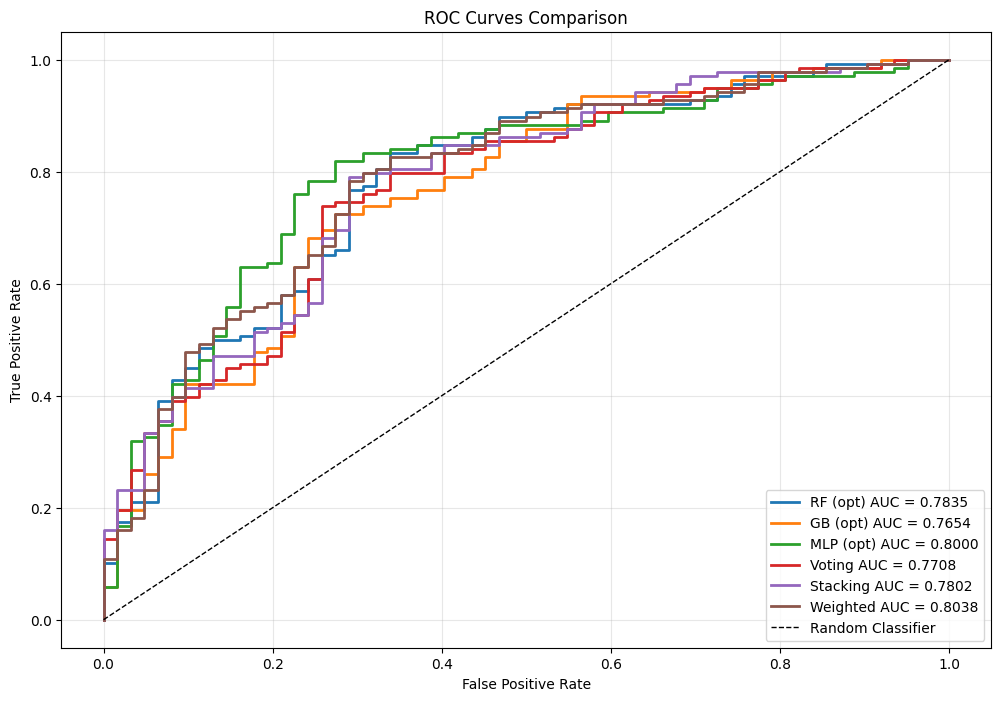

In [81]:
# Визуализация ROC кривых
plt.figure(figsize=(12, 8))

# RF optimized
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_opt_proba)
plt.plot(rf_fpr, rf_tpr, label=f'RF (opt) AUC = {rf_opt_roc_auc:.4f}', linewidth=2)

# GB optimized
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_opt_proba)
plt.plot(gb_fpr, gb_tpr, label=f'GB (opt) AUC = {gb_opt_roc_auc:.4f}', linewidth=2)

# MLP optimized
mlp_fpr, mlp_tpr, _ = roc_curve(y_test, mlp_opt_proba)
plt.plot(mlp_fpr, mlp_tpr, label=f'MLP (opt) AUC = {best_mlp_auc:.4f}', linewidth=2)

# Voting
voting_fpr, voting_tpr, _ = roc_curve(y_test, voting_proba)
plt.plot(voting_fpr, voting_tpr, label=f'Voting AUC = {voting_auc:.4f}', linewidth=2)

# Stacking
stacking_fpr, stacking_tpr, _ = roc_curve(y_test, stacking_proba)
plt.plot(stacking_fpr, stacking_tpr, label=f'Stacking AUC = {stacking_auc:.4f}', linewidth=2)

# Weighted average
weighted_fpr, weighted_tpr, _ = roc_curve(y_test, weighted_proba)
plt.plot(weighted_fpr, weighted_tpr, label=f'Weighted AUC = {best_weighted_auc:.4f}', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

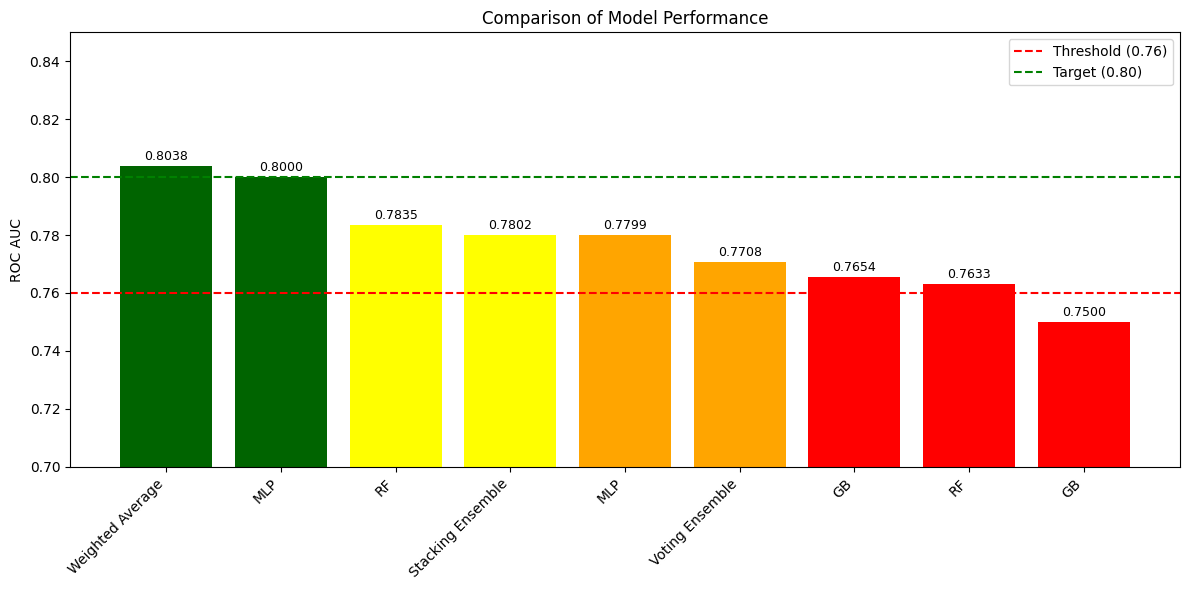

In [82]:
# Визуализация сравнения AUC для всех моделей
model_names = [m[0].split(' (')[0] for m in sorted_models]
auc_values = [m[1] for m in sorted_models]
colors = ['red' if auc < 0.77 else 'orange' if auc < 0.78 else 'yellow' if auc < 0.79 else 'green' if auc < 0.80 else 'darkgreen' for auc in auc_values]

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(model_names)), auc_values, color=colors)
plt.axhline(y=0.76, color='r', linestyle='--', label='Threshold (0.76)')
plt.axhline(y=0.80, color='g', linestyle='--', label='Target (0.80)')

# Добавляем значения на бары
for i, (bar, val) in enumerate(zip(bars, auc_values)):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.001, f'{val:.4f}', 
             ha='center', va='bottom', fontsize=9)

plt.xticks(range(len(model_names)), model_names, rotation=45, ha='right')
plt.ylim(0.70, 0.85)
plt.ylabel('ROC AUC')
plt.title('Comparison of Model Performance')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Визуализация результатов

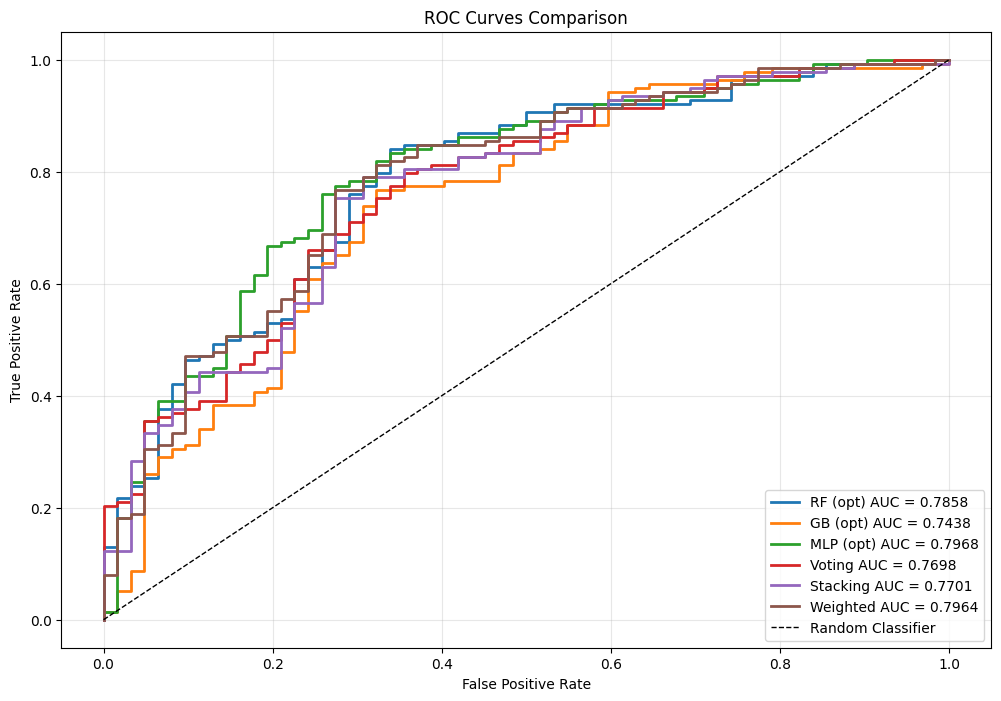

In [23]:
# Визуализация ROC кривых
plt.figure(figsize=(12, 8))

# RF optimized
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_opt_proba)
plt.plot(rf_fpr, rf_tpr, label=f'RF (opt) AUC = {rf_opt_roc_auc:.4f}', linewidth=2)

# GB optimized
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_opt_proba)
plt.plot(gb_fpr, gb_tpr, label=f'GB (opt) AUC = {gb_opt_roc_auc:.4f}', linewidth=2)

# MLP optimized
mlp_fpr, mlp_tpr, _ = roc_curve(y_test, mlp_opt_proba)
plt.plot(mlp_fpr, mlp_tpr, label=f'MLP (opt) AUC = {best_mlp_auc:.4f}', linewidth=2)

# Voting
voting_fpr, voting_tpr, _ = roc_curve(y_test, voting_proba)
plt.plot(voting_fpr, voting_tpr, label=f'Voting AUC = {voting_auc:.4f}', linewidth=2)

# Stacking
stacking_fpr, stacking_tpr, _ = roc_curve(y_test, stacking_proba)
plt.plot(stacking_fpr, stacking_tpr, label=f'Stacking AUC = {stacking_auc:.4f}', linewidth=2)

# Weighted average
weighted_fpr, weighted_tpr, _ = roc_curve(y_test, weighted_proba)
plt.plot(weighted_fpr, weighted_tpr, label=f'Weighted AUC = {best_weighted_auc:.4f}', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

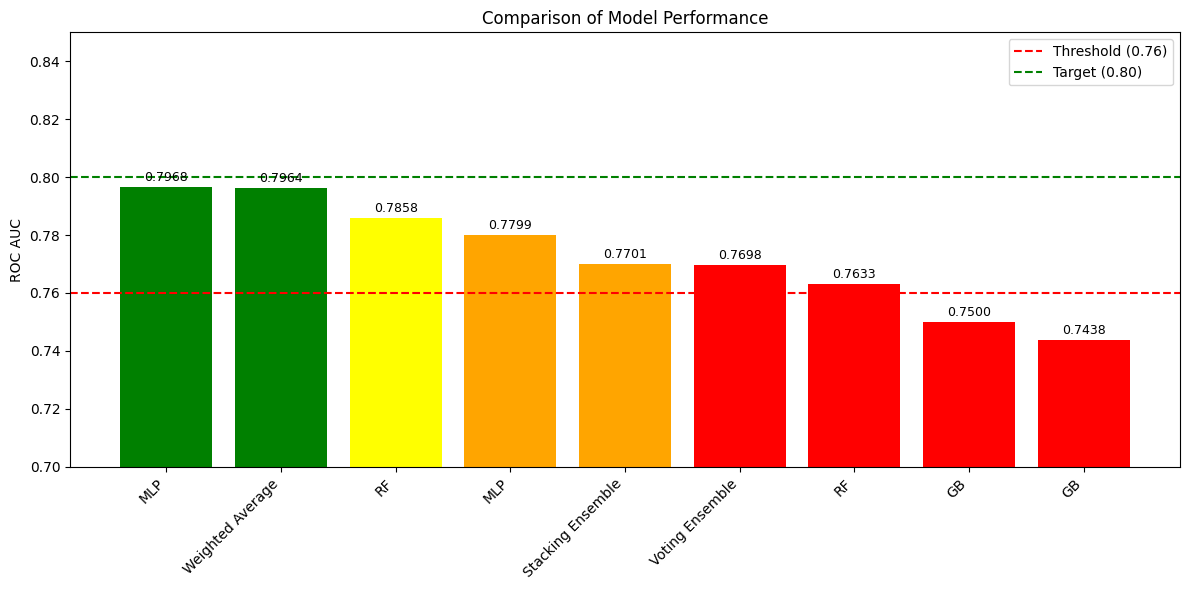

In [24]:
# Визуализация сравнения AUC для всех моделей
model_names = [m[0].split(' (')[0] for m in sorted_models]
auc_values = [m[1] for m in sorted_models]
colors = ['red' if auc < 0.77 else 'orange' if auc < 0.78 else 'yellow' if auc < 0.79 else 'green' if auc < 0.80 else 'darkgreen' for auc in auc_values]

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(model_names)), auc_values, color=colors)
plt.axhline(y=0.76, color='r', linestyle='--', label='Threshold (0.76)')
plt.axhline(y=0.80, color='g', linestyle='--', label='Target (0.80)')

# Добавляем значения на бары
for i, (bar, val) in enumerate(zip(bars, auc_values)):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.001, f'{val:.4f}', 
             ha='center', va='bottom', fontsize=9)

plt.xticks(range(len(model_names)), model_names, rotation=45, ha='right')
plt.ylim(0.70, 0.85)
plt.ylabel('ROC AUC')
plt.title('Comparison of Model Performance')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Выводы

В данной лабораторной работе были выполнены следующие шаги:
1. Загружены данные из файла `german.csv` (датасет кредитоспособности)
2. Выполнена предобработка данных (масштабирование признаков)
3. Обучены базовые модели: Random Forest, Gradient Boosting, MLP
4. Проведена оптимизация гиперпараметров для каждой модели
5. Созданы три типа ансамблей: Voting, Stacking, Weighted Average
6. Сравнены результаты всех моделей

Ансамбли обычно показывают лучшую точность, так как комбинируют сильные стороны разных моделей.

==================================================
СРАВНЕНИЕ РЕЗУЛЬТАТОВ ИЗНАЧАЛЬНО
==================================================
MLP (optimized): 0.7968  
Weighted Average: 0.7964  
RF (optimized): 0.7858  
MLP (baseline): 0.7799  
Stacking Ensemble: 0.7701  
Voting Ensemble: 0.7698  
RF (baseline): 0.7633  
GB (baseline): 0.7500  
GB (optimized): 0.7438  

==================================================
ЛУЧШАЯ МОДЕЛЬ: MLP (optimized) с AUC = 0.7968
==================================================

==================================================
СРАВНЕНИЕ РЕЗУЛЬТАТОВ СТАЛО
==================================================
Weighted Average: 0.8038  
MLP (optimized): 0.8000  
RF (optimized): 0.7835  
Stacking Ensemble: 0.7802  
MLP (baseline): 0.7799  
Voting Ensemble: 0.7708  
GB (optimized): 0.7654  
RF (baseline): 0.7633  
GB (baseline): 0.7500   

==================================================
ЛУЧШАЯ МОДЕЛЬ: MLP (optimized) с AUC = 0.8000
=================================================